In [1]:
import matplotlib as mpl
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import glob

In [2]:
# known_tois = pd.read_csv('../data/toi-catalog.csv', skiprows =2)
known_tois = pd.read_csv('../data/PS_2026.02.17_18.13.58.csv', skiprows =110)

known_tois

,pl_name,hostname,tic_id,gaia_dr3_id,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,...,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,sy_tmag,sy_tmagerr1,sy_tmagerr2,rowupdate,pl_pubdate,releasedate
0,LP 890-9 b,LP 890-9,TIC 44898913,Gaia DR3 4886243456388510720,1,1,2,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.82130,0.000763,-0.000763,14.2683,0.007557,-0.007557,2022-09-14,2022-09,2022-09-14
1,LP 791-18 b,LP 791-18,TIC 181804752,Gaia DR3 3562427951852172288,1,1,3,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.07150,0.001324,-0.001324,13.5571,0.007732,-0.007732,2023-05-14,2023-05,2023-05-14
2,LP 791-18 c,LP 791-18,TIC 181804752,Gaia DR3 3562427951852172288,1,1,3,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,15.07150,0.001324,-0.001324,13.5571,0.007732,-0.007732,2023-05-14,2023-05,2023-05-14
3,LHS 3844 b,LHS 3844,TIC 410153553,Gaia DR3 6385548541499112448,1,1,1,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,13.39250,0.000738,-0.000738,11.9238,0.007698,-0.007698,2019-01-22,2019-02,2019-01-24
4,TOI-540 b,TOI-540,TIC 200322593,Gaia DR3 4785886941312921344,1,1,1,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),...,-0.021,12.89380,0.000481,-0.000481,11.5045,0.007318,-0.007318,2020-10-01,2021-01,2020-10-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,TOI-2427 b,TOI-2427,TIC 142937186,Gaia DR3 5055663973297050624,1,1,1,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.024,9.81845,0.000540,-0.000540,9.0138,0.006000,-0.006000,2022-02-15,2022-02,2022-02-15
187,TOI-3757 b,TOI-3757,TIC 445751830,Gaia DR3 996878131494639488,1,1,1,Transit,2022,Transiting Exoplanet Survey Satellite (TESS),...,-0.020,14.13210,0.000442,-0.000442,13.1858,0.007332,-0.007332,2022-08-22,2022-09,2022-08-22
188,TOI-6303 b,TOI-6303,TIC 186810676,Gaia DR3 239050153051494272,1,1,1,Transit,2025,Transiting Exoplanet Survey Satellite (TESS),...,-0.016,13.91140,0.000482,-0.000482,12.9386,0.007343,-0.007343,2025-09-17,2025-07,2025-09-17
189,TOI-2379 b,TOI-2379,TIC 201177276,Gaia DR3 6521531466699512064,1,1,1,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),...,-0.023,14.66010,0.000323,-0.000323,13.6521,0.007308,-0.007308,2024-09-17,2024-10,2024-09-17


In [3]:
glob.glob('../toi_data/*check')[0].split('/')[2].split('-')[1].split('_')[0]

'153078576'

In [4]:
tic_ids = ['TIC '+(file.split('/')[2].split('-')[1].split('_')[0]) for file in glob.glob('../toi_data/*check')]

In [5]:
tic_ids

['TIC 153078576',
 'TIC 332657786',
 'TIC 102734241',
 'TIC 126606859',
 'TIC 166184428',
 'TIC 198485881',
 'TIC 343628284',
 'TIC 220479565',
 'TIC 240968774',
 'TIC 260708537',
 'TIC 286201103',
 'TIC 306996324',
 'TIC 36724087',
 'TIC 387690507',
 'TIC 413248763',
 'TIC 441738827',
 'TIC 95057860',
 'TIC 118327550',
 'TIC 153065527',
 'TIC 181804752',
 'TIC 20182780',
 'TIC 233602827',
 'TIC 260004324',
 'TIC 285048486',
 'TIC 321669174',
 'TIC 351601843',
 'TIC 370133522',
 'TIC 407591297',
 'TIC 4918918',
 'TIC 98796344',
 'TIC 163539739',
 'TIC 193634953',
 'TIC 362249359',
 'TIC 219041246',
 'TIC 239332587',
 'TIC 259377017',
 'TIC 284441182',
 'TIC 305048087',
 'TIC 34068865',
 'TIC 410153553',
 'TIC 439456714',
 'TIC 470381900',
 'TIC 77156829',
 'TIC 103633434',
 'TIC 142748283',
 'TIC 166648874',
 'TIC 200322593',
 'TIC 22233480',
 'TIC 243185500',
 'TIC 261135533',
 'TIC 28900646',
 'TIC 307210830',
 'TIC 348755728',
 'TIC 368287008',
 'TIC 388076422',
 'TIC 445751830',
 '

In [6]:
failed_2 = ['TIC '+(file.split('/')[-1].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/*data')]




failed_1 = ['TIC '+(file.split('/')[-1].split('-')[1].split('_')[0]) for file in glob.glob('../new_toi_data/t*') if 'data' not in file.split('/')[-1]]



In [7]:
failed_2

['TIC 445751830',
 'TIC 46432937',
 'TIC 467179528',
 'TIC 55650590',
 'TIC 142937186',
 'TIC 119585136',
 'TIC 86263325',
 'TIC 95057860',
 'TIC 98796344',
 'TIC 348755728',
 'TIC 343628284',
 'TIC 34068865',
 'TIC 116483514',
 'TIC 420112589',
 'TIC 419411415',
 'TIC 336128819',
 'TIC 422756130',
 'TIC 357501308',
 'TIC 382602147',
 'TIC 417931300',
 'TIC 429358906',
 'TIC 439456714',
 'TIC 439867639',
 'TIC 441738827',
 'TIC 447061717',
 'TIC 44898913',
 'TIC 452866790',
 'TIC 455784423',
 'TIC 458419328',
 'TIC 459323923',
 'TIC 459762279',
 'TIC 468983280',
 'TIC 470381900',
 'TIC 4918918',
 'TIC 50618703',
 'TIC 52005579',
 'TIC 54962195',
 'TIC 67512645',
 'TIC 70899085',
 'TIC 73649615',
 'TIC 77156829',
 'TIC 8348911']

In [8]:
known_tois.columns

Index(['pl_name', 'hostname', 'tic_id', 'gaia_dr3_id', 'default_flag',
       'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility',
       'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper',
       'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax',
       'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade',
       'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1',
       'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1',
       'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1',
       'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen',
       'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol',
       'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1',
       'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype',
       'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad',
       'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 's

In [9]:
known_tois['transit_depth'] = (known_tois.pl_rade/known_tois.st_rad/109.076)**2

In [10]:
searched_tois = known_tois[known_tois['default_flag']==1].reset_index(drop=True)[['tic_id', 'pl_orbper', 'transit_depth']]

# searched_tois.TIC = 'TIC '+str(searched_tois.TIC)


In [11]:
# known_tois.pl_rade/known_tois.st_rad/109.076

In [12]:
# searched_tois = searched_tois[searched_tois['Orbital Period (days) Value']<1E3]

In [13]:
# set(searched_tois['TOI Disposition'])

In [14]:
# searched_tois['Transit Depth Value'] = searched_tois['Transit Depth Value']/1E6
searched_tois

,tic_id,pl_orbper,transit_depth
0,TIC 44898913,2.729903,0.006049
1,TIC 181804752,0.947998,0.003727
2,TIC 181804752,4.989909,0.015082
3,TIC 410153553,0.462929,0.003995
4,TIC 200322593,1.239149,0.001909
...,...,...,...
186,TIC 142937186,1.306001,0.000645
187,TIC 445751830,3.438753,0.031486
188,TIC 186810676,9.485236,0.030442
189,TIC 201177276,5.469383,0.029865


In [15]:
len(set(searched_tois.tic_id))

161

In [16]:
convergence_test_files_singles = glob.glob('../checking_convergence_output/*single*')

In [17]:
convergence_test_files_periodic = glob.glob('../checking_convergence_output/*per*')

In [18]:

converg_tests_singles = pd.concat((pd.read_csv(f, index_col = 0) for f in convergence_test_files_singles), ignore_index=True)
converg_tests_singles.TICID = ['TIC '+str(converg_tests_singles.TICID[x] ) for x in range(len(converg_tests_singles))]

In [19]:
converg_tests_periodic = pd.concat((pd.read_csv(f, index_col = 0) for f in convergence_test_files_periodic), ignore_index=True)
converg_tests_periodic.TICID = ['TIC '+str(converg_tests_periodic.TICID[x] ) for x in range(len(converg_tests_periodic))]

In [20]:
converg_tests_periodic

,TICID,t0,per,depth,converged,conv_on_run
0,TIC 155867025,1816.806000,2.155000,0.044000,True,2.0
1,TIC 144700903,1470.579000,2.325000,0.008000,True,3.0
2,TIC 212957629,1383.758000,3.078000,0.013000,True,2.0
3,TIC 235683377,1717.207000,49.544000,0.001000,True,1.0
4,TIC 188589164,1958.464000,4.203000,0.005000,True,3.0
...,...,...,...,...,...,...
190,TIC 396562848,1791.388503,42.733484,0.002172,False,NaN
191,TIC 18318288,2719.920433,15.333948,0.005396,False,NaN
192,TIC 18318288,2718.784000,12.851000,0.001000,True,2.0
193,TIC 18318288,2721.080000,2.456000,0.003000,True,1.0


In [21]:
real_val_conv_test_singles = converg_tests_singles.copy()

real_val_conv_test_singles['int_multi'] = np.nan
real_val_conv_test_singles['correct'] = False
real_val_conv_test_singles['alias'] = False
real_val_conv_test_singles['true_per'] = np.nan

for indx, row in real_val_conv_test_singles.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.per
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_singles.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)

        if check_per and (np.round(per_int)== 1):
            real_val_conv_test_singles.loc[indx,'correct'] = True
            real_val_conv_test_singles.loc[indx,'alias'] = True
            real_val_conv_test_singles.loc[indx,'int_multi'] = 1
            real_val_conv_test_singles.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int)!= 1):
            real_val_conv_test_singles.loc[indx,'correct'] = False
            real_val_conv_test_singles.loc[indx,'alias'] = True
            real_val_conv_test_singles.loc[indx,'int_multi'] = round(per_int)
            real_val_conv_test_singles.loc[indx,'true_per'] = per_known
        

In [22]:
real_val_conv_test_periodic = converg_tests_periodic.copy()

real_val_conv_test_periodic['int_multi'] = np.nan
real_val_conv_test_periodic['correct'] = False
real_val_conv_test_periodic['alias'] = False
real_val_conv_test_periodic['true_per'] = np.nan

for indx, row in real_val_conv_test_periodic.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.per
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_periodic.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)

        if check_per and (np.round(per_int)== 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = True
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = 1
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int)!= 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = False
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = round(per_int)
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        

In [23]:
real_val_conv_test_singles[real_val_conv_test_singles['TICID'] == 'TIC 445751830']

,TICID,t0,per,depth,converged,conv_on_run,int_multi,correct,alias,true_per


array([[<Axes: title={'center': 'conv_on_run'}>]], dtype=object)

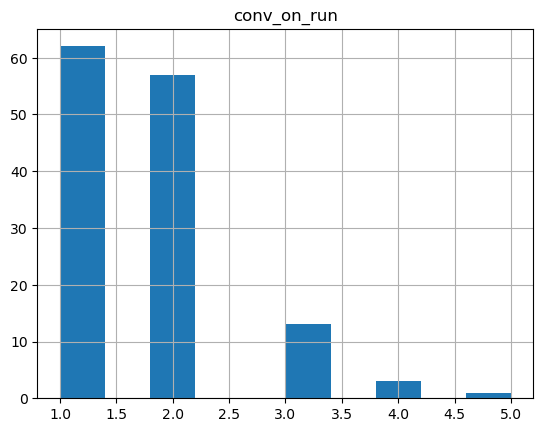

In [24]:
real_val_conv_test_singles.hist('conv_on_run')

array([[<Axes: title={'center': 'conv_on_run'}>]], dtype=object)

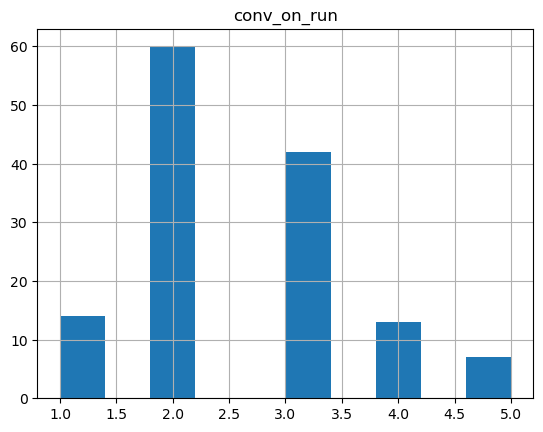

In [25]:
real_val_conv_test_periodic.hist('conv_on_run')

In [26]:
real_val_conv_test_periodic = converg_tests_periodic.copy()

real_val_conv_test_periodic['int_multi'] = np.nan
real_val_conv_test_periodic['correct'] = False
real_val_conv_test_periodic['alias'] = False
real_val_conv_test_periodic['true_per'] = np.nan

for indx, row in real_val_conv_test_periodic.iterrows():
    ticid = row.TICID
    toi = searched_tois[searched_tois['tic_id']==ticid].reset_index(drop=True)
    
    t0_found  = row.t0
    per_found = row.per
    
    for toi_indx, toi_row in toi.iterrows():
#         t0_known = toi_row['Orbital Epoch Value']
        per_known = toi_row['pl_orbper']

#         num_epochs = abs(t0_found-t0_known)/per_known

#         check_int = (abs(num_epochs - np.round(num_epochs, 1)) < 1E-2) or (abs(1/num_epochs - np.round(1/num_epochs, 1)) < 1E-2)

# #         print(abs(num_epochs - np.round(num_epochs, 1)), abs(1/num_epochs - np.round(1/num_epochs, 1)))
# #         print(check_int)
#         if check_int:
#             real_val_conv_test_periodic.loc[indx,'t0'] = t0_known
        
        
        per_int = per_known/per_found
        
        per_int_big = max([per_int, 1/per_int])
        
        check_per = (abs(per_int_big - np.round(per_int_big,4)) < 1E-3) or abs((per_known - per_found)<1E-4)
        print(check_per)

        if check_per and (np.round(per_int)== 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = True
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = 1
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known
        elif check_per and (np.round(per_int)!= 1):
            real_val_conv_test_periodic.loc[indx,'correct'] = False
            real_val_conv_test_periodic.loc[indx,'alias'] = True
            real_val_conv_test_periodic.loc[indx,'int_multi'] = round(per_int)
            
            real_val_conv_test_periodic.loc[indx,'true_per'] = per_known

        

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [27]:

7.727000/2.582000

2.992641363284276

In [28]:
# axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['multiple'] == True) & (real_val_conv_test_singles['correct'] == False)].true_per, 
#          real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['multiple'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
#          marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 1.5, zorder = -1,  alpha = 0.8)


In [29]:
real_val_conv_test_singles

,TICID,t0,per,depth,converged,conv_on_run,int_multi,correct,alias,true_per
0,TIC 186810676,1810.209,6.303,0.040,True,2.0,2.0,False,True,9.485236
1,TIC 240968774,1796.850,47.706,0.000,True,1.0,0.0,False,True,5.971147
2,TIC 102734241,2792.742,1140.476,0.004,True,2.0,0.0,False,True,10.904821
3,TIC 201186294,1799.148,21.008,0.003,True,3.0,0.0,False,True,0.989345
4,TIC 240968774,1796.876,47.675,0.000,True,1.0,0.0,False,True,5.971147
...,...,...,...,...,...,...,...,...,...,...
136,TIC 22233480,2768.704,377.108,0.001,True,1.0,0.0,False,True,7.446280
137,TIC 22233480,2418.838,378.071,0.002,True,2.0,0.0,False,True,7.446280
138,TIC 408636441,1778.075,240.652,0.001,True,3.0,0.0,False,True,18.850190
139,TIC 18318288,2733.203,779.207,0.012,True,4.0,0.0,False,True,1.388872


In [30]:
real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'])]





,TICID,t0,per,depth,converged,conv_on_run,int_multi,correct,alias,true_per


In [31]:
a = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)
b = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)
c = (real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)


real_val_conv_test_periodic[~a & b & ~c].reset_index(drop=True)

,TICID,t0,per,depth,converged,conv_on_run,int_multi,correct,alias,true_per
0,TIC 235683377,1717.207,49.544,0.001,True,1.0,0.0,False,True,0.409068
1,TIC 166648874,1905.230,8.193,0.004,True,2.0,2.0,False,True,15.145469
2,TIC 118327550,1357.287,18.760,0.001,True,3.0,0.0,False,True,7.397225
3,TIC 142748283,1683.653,1.003,0.000,True,2.0,6.0,False,True,6.387840
4,TIC 166184428,1608.703,8.338,0.001,True,1.0,2.0,False,True,16.336334
...,...,...,...,...,...,...,...,...,...,...
56,TIC 310380289,2643.909,35.562,0.002,True,5.0,0.0,False,True,0.648990
57,TIC 310380289,1906.533,11.331,0.003,True,2.0,0.0,False,True,0.648990
58,TIC 153951307,1707.929,31.204,0.001,True,2.0,0.0,False,True,3.294736
59,TIC 310380289,1748.644,28.721,0.002,True,2.0,0.0,False,True,0.648990


In [32]:
a = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)
b = (real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)
c = (real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == True)


real_val_conv_test_singles[a | b  | c]

ok_ticids_singles = list(set(real_val_conv_test_singles[a | b  | c].TICID))


multi_tic_singles = list(set(real_val_conv_test_singles[b].TICID))\


correct_tic_singles = list(set(real_val_conv_test_singles[a].TICID))



In [33]:
d = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)
e = (real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)
f = (real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)

ok_ticids_periodic = list(set(real_val_conv_test_periodic[d | e  | f].TICID))


multi_tic_periodic = list(set(real_val_conv_test_periodic[e].TICID))

correct_tic_periodic = list(set(real_val_conv_test_periodic[d ].TICID))





In [34]:
correct_ticids = list(set(correct_tic_periodic+correct_tic_singles
                         ))

In [35]:
multi_ticids = set(multi_tic_periodic+multi_tic_singles)

In [36]:
double_check_ticids = [ticid for ticid in set(searched_tois.tic_id) if (ticid not in set(correct_ticids)) and ticid in set(multi_ticids) ]


[int(x[4:]) for x in double_check_ticids]
print(double_check_ticids)


['TIC 12421862', 'TIC 321669174', 'TIC 119584412', 'TIC 118327550', 'TIC 240968774', 'TIC 243641947', 'TIC 332657786', 'TIC 166648874', 'TIC 36724087', 'TIC 329148988', 'TIC 289164482', 'TIC 310380289', 'TIC 408636441', 'TIC 284441182', 'TIC 201186294', 'TIC 261257684', 'TIC 394357918', 'TIC 235683377', 'TIC 308120029', 'TIC 351601843', 'TIC 28900646', 'TIC 102734241', 'TIC 37749396']


In [37]:
len(set(ok_ticids_periodic+ok_ticids_singles))

78

In [38]:
bad_ticids = [ticid for ticid in set(searched_tois.tic_id) if ticid not in set(ok_ticids_periodic+ok_ticids_singles)]

In [39]:
bad_ticids

['TIC 142937186',
 'TIC 4918918',
 'TIC 305048087',
 'TIC 77156829',
 'TIC 86263325',
 'TIC 357501308',
 'TIC 200322593',
 'TIC 348755728',
 'TIC 288144647',
 'TIC 46432937',
 'TIC 20182780',
 'TIC 103633434',
 'TIC 259233660',
 'TIC 467179528',
 'TIC 219875976',
 'TIC 50618703',
 'TIC 458419328',
 'TIC 439867639',
 'TIC 307210830',
 'TIC 259168516',
 'TIC 54962195',
 'TIC 16005254',
 'TIC 26054627',
 'TIC 230055368',
 'TIC 422756130',
 'TIC 441738827',
 'TIC 95057860',
 'TIC 73649615',
 'TIC 67512645',
 'TIC 193634953',
 'TIC 112115898',
 'TIC 382602147',
 'TIC 307809773',
 'TIC 328513434',
 'TIC 459323923',
 'TIC 452866790',
 'TIC 193336820',
 'TIC 343628284',
 'TIC 445751830',
 'TIC 260004324',
 'TIC 336128819',
 'TIC 470381900',
 'TIC 163539739',
 'TIC 359271092',
 'TIC 153065527',
 'TIC 34068865',
 'TIC 119585136',
 'TIC 455784423',
 'TIC 260708537',
 'TIC 372207328',
 'TIC 468983280',
 'TIC 98796344',
 'TIC 261135533',
 'TIC 429358906',
 'TIC 413248763',
 'TIC 8348911',
 'TIC 556

In [40]:
len(set(searched_tois.tic_id))

161

In [41]:
searched_tois = searched_tois.sort_values('transit_depth')

In [42]:
searched_tois

,tic_id,pl_orbper,transit_depth
94,TIC 260708537,1.744700,0.000145
110,TIC 34068865,0.321923,0.000196
116,TIC 359271092,7.576860,0.000254
119,TIC 380887434,0.399444,0.000294
168,TIC 116483514,1.452053,0.000320
...,...,...,...
77,TIC 243641947,2.592618,0.079913
48,TIC 218795833,1.265233,0.091456
53,TIC 459323923,2.652062,0.118871
12,TIC 67512645,3.370772,0.149026


In [43]:
searched_tois

,tic_id,pl_orbper,transit_depth
94,TIC 260708537,1.744700,0.000145
110,TIC 34068865,0.321923,0.000196
116,TIC 359271092,7.576860,0.000254
119,TIC 380887434,0.399444,0.000294
168,TIC 116483514,1.452053,0.000320
...,...,...,...
77,TIC 243641947,2.592618,0.079913
48,TIC 218795833,1.265233,0.091456
53,TIC 459323923,2.652062,0.118871
12,TIC 67512645,3.370772,0.149026


In [44]:
a

0      False
1      False
2      False
3      False
4      False
       ...  
136    False
137    False
138    False
139    False
140    False
Length: 141, dtype: bool

In [45]:
len(glob.glob('../new_toi_data/t*'))#-len(failed_2)

158

In [46]:
failed_2

['TIC 445751830',
 'TIC 46432937',
 'TIC 467179528',
 'TIC 55650590',
 'TIC 142937186',
 'TIC 119585136',
 'TIC 86263325',
 'TIC 95057860',
 'TIC 98796344',
 'TIC 348755728',
 'TIC 343628284',
 'TIC 34068865',
 'TIC 116483514',
 'TIC 420112589',
 'TIC 419411415',
 'TIC 336128819',
 'TIC 422756130',
 'TIC 357501308',
 'TIC 382602147',
 'TIC 417931300',
 'TIC 429358906',
 'TIC 439456714',
 'TIC 439867639',
 'TIC 441738827',
 'TIC 447061717',
 'TIC 44898913',
 'TIC 452866790',
 'TIC 455784423',
 'TIC 458419328',
 'TIC 459323923',
 'TIC 459762279',
 'TIC 468983280',
 'TIC 470381900',
 'TIC 4918918',
 'TIC 50618703',
 'TIC 52005579',
 'TIC 54962195',
 'TIC 67512645',
 'TIC 70899085',
 'TIC 73649615',
 'TIC 77156829',
 'TIC 8348911']

Using matplotlib backend: module://matplotlib_inline.backend_inline


(-10.0, 100.0)

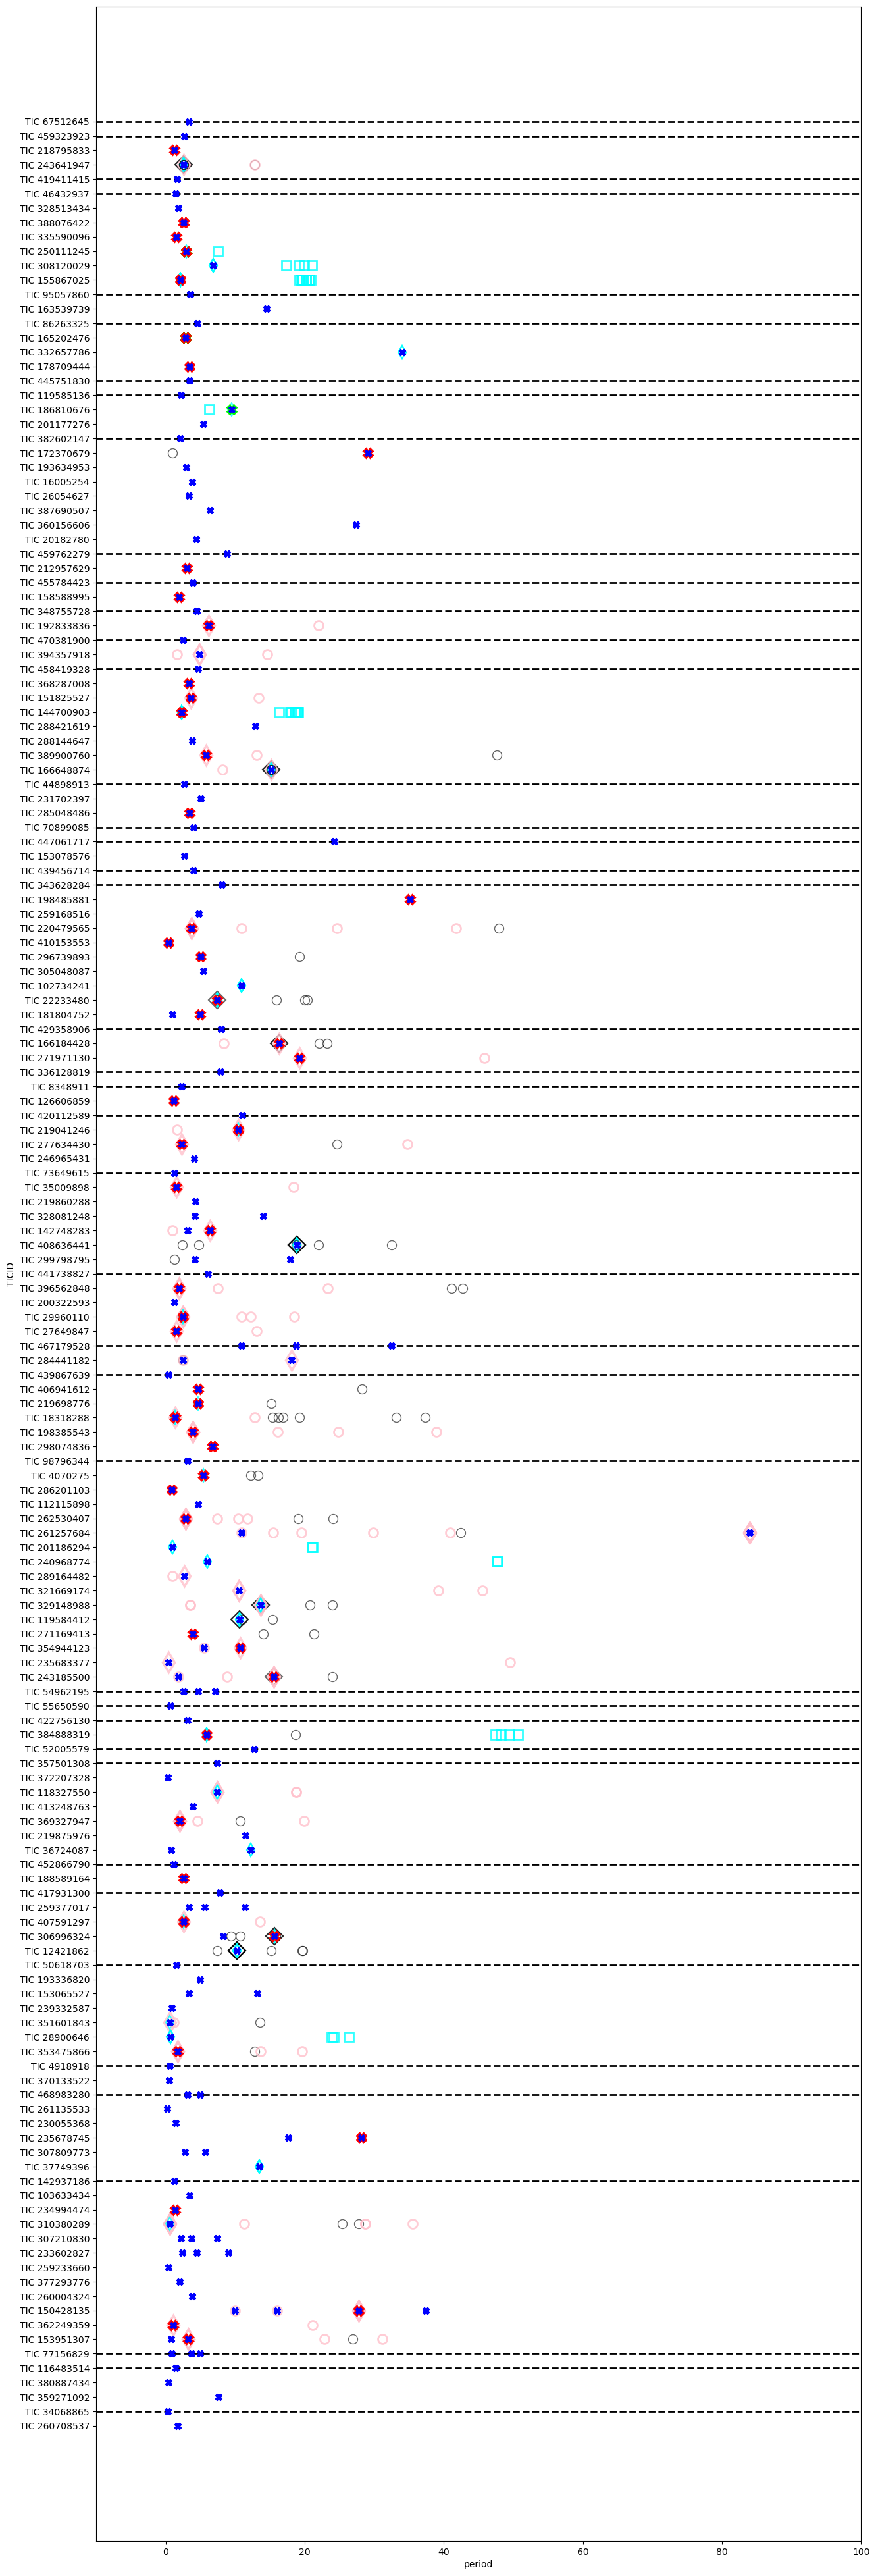

In [47]:

%matplotlib 

fig, axs = plt.subplots(1, figsize=(15, 50))



axs.scatter(searched_tois['pl_orbper'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E3)

axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['correct'] == True)].TICID.astype(str), 
         marker='X', markersize=10,  markerfacecolor='none', markeredgecolor='red', linestyle='None', markeredgewidth = 2, zorder = 2000, alpha = 1)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].TICID.astype(str), 
         marker='d', markersize=15,  markerfacecolor='none', markeredgecolor='pink', linestyle='None', markeredgewidth = 2.5, zorder = 0,  alpha = 0.8)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True) & (real_val_conv_test_periodic['alias'] == True) & (real_val_conv_test_periodic['correct'] == False)].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='pink', linestyle='None', markeredgewidth = 2, zorder = 200,  alpha = 0.8)


axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True)  & (real_val_conv_test_periodic['alias'] == False)].per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == True)  & (real_val_conv_test_periodic['alias'] == False)].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='orange', linestyle='None', markeredgewidth = 2, zorder = 75,  alpha = 0.5)

axs.plot(real_val_conv_test_periodic[real_val_conv_test_periodic['converged'] == False].per, 
         real_val_conv_test_periodic[real_val_conv_test_periodic['converged'] == False].TICID.astype(str), 
         marker='o', markersize=10,  markerfacecolor='none', markeredgecolor='black', linestyle='None', markeredgewidth = 1, zorder = 20,  alpha = 0.6)

axs.plot(real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)].true_per, 
         real_val_conv_test_periodic[(real_val_conv_test_periodic['converged'] == False) & (real_val_conv_test_periodic['correct'] == True)].TICID.astype(str), 
         marker='D', markersize=13,  markerfacecolor='none', markeredgecolor='black', linestyle='None', markeredgewidth = 1.5, zorder = -1,  alpha = 0.6)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)].true_per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['correct'] == True)].TICID.astype(str), 
         marker='X', markersize=10,  markerfacecolor='none', markeredgecolor='lime', linestyle='None', markeredgewidth = 2, zorder = 1000, alpha = 1)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].true_per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
         marker='d', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 1.5, zorder = 0,  alpha = 0.8)


axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True) & (real_val_conv_test_singles['alias'] == True) & (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
         marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 2, zorder = 100,  alpha = 0.8)


axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True)  & (real_val_conv_test_singles['alias'] == False)].per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == True)  & (real_val_conv_test_singles['alias'] == False)].TICID.astype(str), 
         marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='navy', linestyle='None', markeredgewidth = 2, zorder = 50,  alpha = 0.5)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == False)].per, real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False)& (real_val_conv_test_singles['correct'] == False)].TICID.astype(str), 
         marker='s', markersize=10,  markerfacecolor='none', markeredgecolor='green', linestyle='None', markeredgewidth = 1, zorder = 10,  alpha = 0.6)

axs.plot(real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == True)].true_per, 
         real_val_conv_test_singles[(real_val_conv_test_singles['converged'] == False) & (real_val_conv_test_singles['correct'] == True)].TICID.astype(str), 
         marker='D', markersize=10,  markerfacecolor='none', markeredgecolor='green', linestyle='None', markeredgewidth = 1, zorder = -1,  alpha = 0.6)



axs.hlines(failed_2, -10, 100, color = 'k',ls = '--', zorder = -1, lw = 2)

# axs.scatter(searched_tois['Orbital Epoch Value'], searched_tois['TIC'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 100)
axs.scatter(searched_tois['pl_orbper'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E4)
# axs.scatter(searched_tois['transit_depth'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E3)

# axs.set_yticks([str(tic) for tic in tic_ids])

# y1, y2 = axs.get_ylim()
# axs.vlines(0.25, y1, y2)
    
    
# axs.set_ylim(y1, y2)
axs.set_xlabel('period')
axs.set_ylabel('TICID')
axs.set_xlim(-10, 100)

In [48]:
# fig, axs = plt.subplots(1, figsize=(10, 50))

# axs.plot(converg_tests_singles[converg_tests_singles['converged'] == True].per, converg_tests_singles[converg_tests_singles['converged'] == True].TICID.astype(str), marker='o', markersize=10, 
#             markerfacecolor='none', markeredgecolor='green', linestyle='None', markeredgewidth = 2.5, zorder = 500)

# axs.plot(converg_tests_singles[converg_tests_singles['converged'] == False].per, converg_tests_singles[converg_tests_singles['converged'] == False].TICID.astype(str), marker='o', markersize=10, 
#             markerfacecolor='none', markeredgecolor='peach', linestyle='None', markeredgewidth = 1, zorder = 10)


# axs.plot(real_val_conv_test_singles[real_val_conv_test_singles['converged'] == True].per, real_val_conv_test_singles[real_val_conv_test_singles['converged'] == True].TICID.astype(str), marker='o', markersize=10, 
#             markerfacecolor='none', markeredgecolor='teal', linestyle='None', markeredgewidth = 2.5, zorder = 50, alpha = 0.7)

# axs.plot(real_val_conv_test_singles[real_val_conv_test_singles['converged'] == False].per, real_val_conv_test_singles[real_val_conv_test_singles['converged'] == False].TICID.astype(str), marker='o', markersize=10, 
#             markerfacecolor='none', markeredgecolor='cyan', linestyle='None', markeredgewidth = 1, zorder = 10, alpha = 0.7)


# # axs.scatter(searched_tois['Orbital Epoch Value'], searched_tois['TIC'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 100)
# axs.scatter(searched_tois['pl_orbper'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E3)
# # axs.scatter(searched_tois['transit_depth'], searched_tois['tic_id'].astype(str), color = 'b', marker = 'X', s = 50, zorder = 1E3)

# # axs.set_yticks([str(tic) for tic in tic_ids])
# axs.set_xlabel('period')
# axs.set_ylabel('TICID')